In [1]:
# import modules

import pandas as pd
import networkx as nx

import matplotlib.pyplot as plt

# Utility functions

In [2]:
def pprint_edges(nx_view, keys=None):
    """Pretty print edges between 2 nodes

    Args:
        nx_view (EdgeView): 2 nodes
        keys (list(str)): Names of the edges attribute to print. Defaults to None.
    """
    for k, dct in nx_view.items():
        if keys is None:
            keys = dct.keys()
        else: 
            if isinstance(keys, str):
                keys = [keys]
            temp = {sub_k: sub_v for sub_k, sub_v in dct.items() if sub_k in keys}
            dct = temp
        print(f"Edge #{k} with attributes {dct}")


def pprint(nx_view, keys=None):
    """Print information about a node / edge from a nx.Graph

    Args:
        nx_view (EdgeView or NodeView): a node or an edge from a graph
        keys (list[str], optional): attributes to show. Defaults to None (i.e. show all)
    """
    if isinstance(nx_view, nx.classes.coreviews.AdjacencyView):
        for node, edges_dct in nx_view.items():
            print(f"{node}")
            pprint_edges(edges_dct)
    elif isinstance(nx_view, nx.classes.coreviews.AtlasView):
        pprint_edges(nx_view, keys)

# The Model

In [3]:
def build_network(dfs, params, attrs_map):
    """Build a network based on tabular representation of products composition.
    
    The original tabular data should ahve the following format:
    | Source | Target | Scope (=Ancestors) |
    
    The nodes of the graph represents the different substances
    The (directed) edges represent a composition relationship between 2 entities:
        - direction points from the parent to the child
        - 2 nodes can have multiple edges connecting them to one another (multigraph)

    Args:
        dfs (dict): dict of DataFrame
        params (tuple): names of sheet and columns. The order is the following:
            (sheet, source, target, ancestors)
        attrs_map (dict): mapping for the columns to be renamed

    Returns:
        nx.graph: a graph representation of the products composition
    """
    G = nx.MultiDiGraph()
    for sheet, source, target, *ancestors in params:
        df = dfs[sheet].rename(columns=attrs_map).copy()
        df['ancestors'] = list(df[[*ancestors, source]].itertuples(index=False, name=None))
        df['ancestors'] = df['ancestors'].apply(set)
        # append to graph with year, share... + all ancestors as edge attribute
        G = nx.compose(
            G,
            nx.from_pandas_edgelist(
                df=df,
                source=source,
                target=target,
                edge_attr=df.columns.drop([*ancestors, source, target]).values.tolist(),
                create_using=nx.MultiDiGraph,
            )
        )
        # and add substance type (products, component, material...) as node attribute
        for _type in [source, target]:
            attribute_type = {key: {"type": _type} for key in df[_type].unique()}
            nx.set_node_attributes(G, attribute_type)
            
    return G


def successors_subgraph(graph, node):
    """Generate a subgraph with all the successors of a node

    Args:
        graph (nx.graph): the network model
        node (node): The ancestor

    Returns:
        nx.Graph: subgraph of graph
    """
    edges = [(u, v, key) for u, v, key, data in graph.edges(keys=True, data=True) 
        if node in data['ancestors']
    ]
    return nx.edge_subgraph(graph, edges)



def ancestors_subgraph(graph, node, get_ancestors=False):
    """Generate a subgraph with all the ancestors of a node

    Args:
        graph (nx.graph): the network model
        node (node): The successors

    Returns:
        nx.Graph: subgraph of graph
    """
    ancestors = set()
    edges = set()
    
    parents = [*graph.predecessors(node)]
    for parent in parents:
        for edge in graph[parent][node]:
            ancestors.update(graph[parent][node][edge]['ancestors'])

    # only keeps source ancestors
    sources = [n for n in ancestors if not list(graph.predecessors(n))]
    # keep tracks of all the edges that connect all ancestors to node
    for source in sources:
        for path in nx.all_simple_edge_paths(G, source, node, cutoff=None):
            edges.update(path)

    if get_ancestors:
        return (nx.edge_subgraph(graph, edges), tuple(sources))
    return nx.edge_subgraph(graph, edges)



def print_substances(graph, **kwargs):
    # nodes = (n for n in graph.nodes if graph[n][k] == v for k,v in kwargs.items())
    # return list(nodes)
    nodes = []
    for node, dct in graph.nodes.data():
        keep = True
        for k,v in kwargs.items():
            if dct[k] != v:
                keep = False
                break
        if keep == True:
            nodes.append(node)
    return nodes



def print_composition(graph, source, targets=None, keys=None):
    """ Display information about the relationship between a predecessor (source)
    and a successor (target) (or with all the rest of the graph if None).
    It will show the edges attributes along every path leading from source to target

    Args:
        graph (nx.graph): the network model
        source (node): predecessor
        targets (node): successor
        keys (list(str)) = name of the attribute to display; Default to all attributes
    """
    subgraph = successors_subgraph(graph, source)
    if targets is None:
        targets = [node for node in graph.nodes if not graph[node]]
    
    for path in nx.all_simple_edge_paths(subgraph, source, targets, cutoff=None):
        # print(path)
        for u,v,k in path:
            print(f'\n{u} --> {v} (#{k})')
            dct = subgraph.edges[(u,v,k)]
            if keys is not None:
                if isinstance(keys, str):
                    keys = [keys]
                dct = {idx:val for idx,val in subgraph.edges[(u,v,k)].items() if idx in keys}
            print(dct)


def print_contains(graph, node, keys=None):
    """ Display information about the relationship between all the ancestors of a node
    It will show the edges attributes along every path leading from an ancestors to the node.

    Args:
        graph (nx.graph): the network model
        node (node): predecessor
        keys (list(str)) = name of the attribute to display; Default to all attributes
    """
    graph_ancestors, sources = ancestors_subgraph(graph, node, get_ancestors=True)
    for source in sources:
        print_composition(graph_ancestors, source, node, keys)

# Dataset

In [4]:
FILEPATH = "../../data/WEE/Toy_WEEE.xlsx"
data = pd.read_excel(FILEPATH, sheet_name=None)

# params = (sheet, source, target, ancestor)
params = (
    ('components', 'Category', 'Component'),
    ('materials', 'Category', 'Material'),
    ('elements_in_mat', 'Material', 'Element', 'Category'),
    ('elements_in_comp', 'Component', 'Element', 'Category'),
)

attributes_dct = {
    'WEEE_t': 'value',
    'Share_Component': 'share',
    'Share_Material': 'share',
    'Share_element': 'share',
}


# Modelling & testing

![Example](./Network_example.jpeg)

In [5]:
# Model the excel file into a network
G = build_network(data, params, attributes_dct)

In [6]:
# Show all the nodes (i.e. Products - Components - Materials - Elements)
[*G.nodes]

['Cat_1',
 'Cables',
 'PCBUnspecified',
 'Cat_2',
 'Cat_3',
 'Cat_4a',
 'Cat_4b',
 'Cat_5',
 'Cat_6',
 'AlloyZincUnspecified',
 'AluminiumAlloyUnspecified',
 'Brass',
 'Bronze',
 'CopperAlloyUnspecified',
 'NiAlloyUnspecified',
 'AgAlloyUnspecified',
 'Al',
 'Cu']

In [7]:
# Print only some substances
substance = 'Element'  # Element Material, Component Category 
print_substances(G, type=substance)

['Al', 'Cu']

In [8]:
# Check attribute of a node (default Networkx view)
G.nodes['AluminiumAlloyUnspecified']

{'type': 'Material'}

In [9]:
# Check edges from a node (default Networkx view)
G['AluminiumAlloyUnspecified']

AdjacencyView({'Al': {0: {'Year': 2020, 'share': 0.9699, 'ancestors': {'Cat_1', 'AluminiumAlloyUnspecified'}}, 1: {'Year': 2020, 'share': 0.9699, 'ancestors': {'Cat_2', 'AluminiumAlloyUnspecified'}}, 2: {'Year': 2020, 'share': 0.9699, 'ancestors': {'Cat_3', 'AluminiumAlloyUnspecified'}}, 3: {'Year': 2020, 'share': 0.9699, 'ancestors': {'Cat_4a', 'AluminiumAlloyUnspecified'}}, 4: {'Year': 2020, 'share': 0.9699, 'ancestors': {'AluminiumAlloyUnspecified', 'Cat_4b'}}, 5: {'Year': 2020, 'share': 0.9699, 'ancestors': {'Cat_5', 'AluminiumAlloyUnspecified'}}, 6: {'Year': 2020, 'share': 0.969900000000001, 'ancestors': {'Cat_6', 'AluminiumAlloyUnspecified'}}}})

In [10]:
# Similarly for edges
layer = 0
G.edges['Cables', 'Al', layer]

{'Year': 2020, 'share': 0.0357, 'ancestors': {'Cables', 'Cat_1'}}

In [11]:
# Check edges between 2 nodes (default Networkx view)
G['Cables']['Al']

AtlasView({0: {'Year': 2020, 'share': 0.0357, 'ancestors': {'Cat_1', 'Cables'}}, 1: {'Year': 2020, 'share': 0.0264934474912248, 'ancestors': {'Cables', 'Cat_2'}}, 2: {'Year': 2020, 'share': 0.0264000051133492, 'ancestors': {'Cables', 'Cat_4a'}}, 3: {'Year': 2020, 'share': 0.0357, 'ancestors': {'Cables', 'Cat_4b'}}, 4: {'Year': 2020, 'share': 0.0357, 'ancestors': {'Cables', 'Cat_5'}}, 5: {'Year': 2020, 'share': 0.0357, 'ancestors': {'Cables', 'Cat_6'}}})

In [12]:
# pretty print information about edges between 2 nodes
pprint(G['Cables']['Al'])

Edge #0 with attributes {'Year': 2020, 'share': 0.0357, 'ancestors': {'Cat_1', 'Cables'}}
Edge #1 with attributes {'Year': 2020, 'share': 0.0264934474912248, 'ancestors': {'Cables', 'Cat_2'}}
Edge #2 with attributes {'Year': 2020, 'share': 0.0264000051133492, 'ancestors': {'Cables', 'Cat_4a'}}
Edge #3 with attributes {'Year': 2020, 'share': 0.0357, 'ancestors': {'Cables', 'Cat_4b'}}
Edge #4 with attributes {'Year': 2020, 'share': 0.0357, 'ancestors': {'Cables', 'Cat_5'}}
Edge #5 with attributes {'Year': 2020, 'share': 0.0357, 'ancestors': {'Cables', 'Cat_6'}}


In [13]:
# pretty print information about all edges from a node
pprint(G['AluminiumAlloyUnspecified'])

Al
Edge #0 with attributes {'Year': 2020, 'share': 0.9699, 'ancestors': {'Cat_1', 'AluminiumAlloyUnspecified'}}
Edge #1 with attributes {'Year': 2020, 'share': 0.9699, 'ancestors': {'Cat_2', 'AluminiumAlloyUnspecified'}}
Edge #2 with attributes {'Year': 2020, 'share': 0.9699, 'ancestors': {'Cat_3', 'AluminiumAlloyUnspecified'}}
Edge #3 with attributes {'Year': 2020, 'share': 0.9699, 'ancestors': {'Cat_4a', 'AluminiumAlloyUnspecified'}}
Edge #4 with attributes {'Year': 2020, 'share': 0.9699, 'ancestors': {'AluminiumAlloyUnspecified', 'Cat_4b'}}
Edge #5 with attributes {'Year': 2020, 'share': 0.9699, 'ancestors': {'Cat_5', 'AluminiumAlloyUnspecified'}}
Edge #6 with attributes {'Year': 2020, 'share': 0.969900000000001, 'ancestors': {'Cat_6', 'AluminiumAlloyUnspecified'}}


In [14]:
# Show the composition of a substance
print_composition(G, "Cables")


Cables --> Al (#0)
{'Year': 2020, 'share': 0.0357, 'ancestors': {'Cat_1', 'Cables'}}

Cables --> Al (#1)
{'Year': 2020, 'share': 0.0264934474912248, 'ancestors': {'Cables', 'Cat_2'}}

Cables --> Al (#2)
{'Year': 2020, 'share': 0.0264000051133492, 'ancestors': {'Cables', 'Cat_4a'}}

Cables --> Al (#3)
{'Year': 2020, 'share': 0.0357, 'ancestors': {'Cables', 'Cat_4b'}}

Cables --> Al (#4)
{'Year': 2020, 'share': 0.0357, 'ancestors': {'Cables', 'Cat_5'}}

Cables --> Al (#5)
{'Year': 2020, 'share': 0.0357, 'ancestors': {'Cables', 'Cat_6'}}

Cables --> Cu (#0)
{'Year': 2020, 'share': 0.17235, 'ancestors': {'Cat_1', 'Cables'}}

Cables --> Cu (#1)
{'Year': 2020, 'share': 0.261212115707158, 'ancestors': {'Cables', 'Cat_2'}}

Cables --> Cu (#2)
{'Year': 2020, 'share': 0.216544513515975, 'ancestors': {'Cables', 'Cat_4a'}}

Cables --> Cu (#3)
{'Year': 2020, 'share': 0.17235, 'ancestors': {'Cables', 'Cat_4b'}}

Cables --> Cu (#4)
{'Year': 2020, 'share': 0.173215506496447, 'ancestors': {'Cables', '

In [15]:
# Show the composition of a substance but filter attributes
print_composition(G, source='Cables', keys='share')


Cables --> Al (#0)
{'share': 0.0357}

Cables --> Al (#1)
{'share': 0.0264934474912248}

Cables --> Al (#2)
{'share': 0.0264000051133492}

Cables --> Al (#3)
{'share': 0.0357}

Cables --> Al (#4)
{'share': 0.0357}

Cables --> Al (#5)
{'share': 0.0357}

Cables --> Cu (#0)
{'share': 0.17235}

Cables --> Cu (#1)
{'share': 0.261212115707158}

Cables --> Cu (#2)
{'share': 0.216544513515975}

Cables --> Cu (#3)
{'share': 0.17235}

Cables --> Cu (#4)
{'share': 0.173215506496447}

Cables --> Cu (#5)
{'share': 0.17235}


In [16]:
# Show if (and how) a substance is composed of another one
print_composition(G, source='Cat_1', targets='Al', keys='share')


Cat_1 --> Cables (#0)
{'share': 0.00265133390018257}

Cables --> Al (#0)
{'share': 0.0357}

Cat_1 --> PCBUnspecified (#0)
{'share': 0.00213150002698564}

PCBUnspecified --> Al (#0)
{'share': 0.0145389775088645}

Cat_1 --> AlloyZincUnspecified (#0)
{'share': 0.00431971152936112}

AlloyZincUnspecified --> Al (#0)
{'share': 0.04}

Cat_1 --> AluminiumAlloyUnspecified (#0)
{'share': 0.0478712286318259}

AluminiumAlloyUnspecified --> Al (#0)
{'share': 0.9699}


In [17]:
# Show if (and what) a substance is part of
print_contains(G, node='Cables')


Cat_4a --> Cables (#0)
{'Year': 2020, 'share': 0.0153328001545317, 'ancestors': {'Cat_4a'}}

Cat_5 --> Cables (#0)
{'Year': 2020, 'share': 0.0855942664317333, 'ancestors': {'Cat_5'}}

Cat_1 --> Cables (#0)
{'Year': 2020, 'share': 0.00265133390018257, 'ancestors': {'Cat_1'}}

Cat_2 --> Cables (#0)
{'Year': 2020, 'share': 0.0169008031177909, 'ancestors': {'Cat_2'}}

Cat_6 --> Cables (#0)
{'Year': 2020, 'share': 0.0508848339300003, 'ancestors': {'Cat_6'}}

Cat_4b --> Cables (#0)
{'Year': 2020, 'share': 0.00281140135313542, 'ancestors': {'Cat_4b'}}


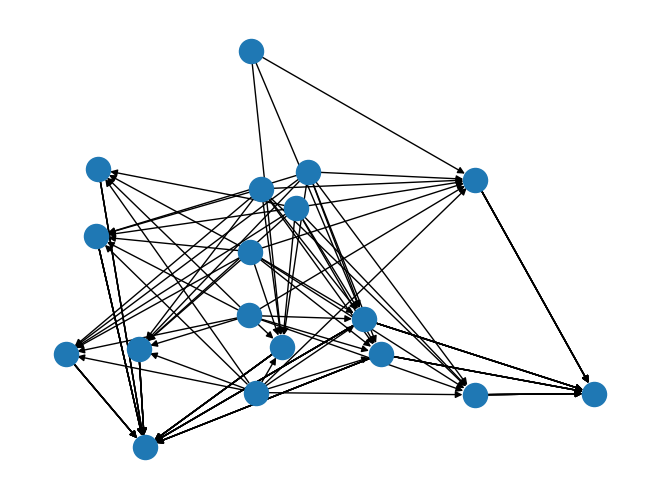

In [18]:
# Show the network in matplotlib (WIP)
pos = nx.spring_layout(G, k=0.5, iterations=20)
nx.draw(G, pos)
plt.show()

# Processes

The system is therefore:
- a set of connected processes (another network) 
- a mathematical function that transforms the current composition network into a new network